# Étude du parc de 503 bâtiments

Le parc qui sert à entraîner le simulateur de courbe de charge (`timeseries_net`) et qui servira
à l'étude de flexibilité (`07_flexibilite`). Trois questions :

1. **Ce qu'est le parc** — composition, climat, enveloppe, équipements.
2. **Comment il consomme** — niveaux annuels et surtout *formes de charge* horaires.
3. **S'il est une base saine pour l'entraînement** — représentativité, découpage train/validation,
   risque de mémorisation.

> **Pourquoi cette étude.** Le 03/08, un `[:30]` laissé dans `timeseries_net` a fait tomber le R²
> total de 0.834 à 0.558. La cause n'était pas le modèle : `nn_buildings.csv` est **groupé par
> état**, donc une tranche `[:30]` ne prélève pas 30 bâtiments au hasard mais 22 FL + 6 TX + 2 GA —
> un parc uniquement chaud où le chauffage ne pèse plus que 7 % du total au lieu de 30 %.
> D'où la nécessité de savoir précisément ce que contient le parc avant de s'en servir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path().resolve().parent.parent / 'data' / 'processed'

USAGES = ['total', 'chauffage', 'clim', 'eau_chaude']
TGT    = ['out.electricity.' + t + '.energy_consumption..kwh'
          for t in ['total', 'heating', 'cooling', 'hot_water']]
SETP   = ['out.schedules.heating_setpoint..c', 'out.schedules.cooling_setpoint..c']
TEXT   = 'out.outdoor_air_drybulb_temp..c'

# Palette catégorielle validée (slots 1-4, ordre fixe : l'ordre EST le mécanisme de sûreté
# daltonisme, il ne se permute pas). Le mapping est aussi sémantique : orange = chaud,
# aqua = froid.
COUL = {'total': '#2a78d6', 'chauffage': '#eb6834', 'clim': '#1baf7a', 'eau_chaude': '#eda100'}
GRILLE, AXE, ENCRE = '#e1e0d9', '#c3c2b7', '#52514e'

def deco(ax, titre='', x='', y=''):
    """Grille et axes en retrait : les données au premier plan, le décor au second."""
    ax.set(title=titre, xlabel=x, ylabel=y)
    ax.grid(True, color=GRILLE, lw=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXE)
    ax.tick_params(colors=ENCRE, labelsize=9)
    return ax

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'font.size': 10, 'axes.titlesize': 11, 'legend.frameon': False})

ids = pd.read_csv(DATA / 'nn_buildings.csv')['bldg_id'].values
print(f'parc : {len(ids)} bâtiments')

parc : 503 bâtiments


## 1. Ce qu'est le parc

### 1.1 Un parc filtré, pas un échantillon de ResStock

Premier point à avoir en tête avant toute interprétation : les trois filtres ci-dessous sont
**absolus** — 503/503. Le parc ne représente donc pas le bâti résidentiel américain, mais un
segment précis : la maison individuelle occupée à chauffage électrique. C'est cohérent avec
l'objet (un modèle de consommation *électrique*), mais ça borne le domaine de validité du
simulateur, et ça doit être dit quand on présente ses résultats.

In [2]:
COLS = ['bldg_id', 'in.state', 'in.county', 'in.ashrae_iecc_climate_zone_2004',
        'in.geometry_building_type_recs', 'in.vintage', 'in.sqft..ft2',
        'in.heating_fuel', 'in.hvac_cooling_type', 'in.water_heater_fuel',
        'in.hvac_heating_type', 'in.vacancy_status', 'in.occupants', 'upgrade'] + TGT

meta = pd.read_parquet(DATA / 'metadata_clean.parquet', columns=COLS)
parc = meta.set_index('bldg_id').loc[ids]

for c in ['in.geometry_building_type_recs', 'in.heating_fuel', 'in.vacancy_status']:
    vc = parc[c].value_counts()
    print(f'{c:38} {vc.index[0]:24} {vc.iloc[0]}/{len(parc)}')

in.geometry_building_type_recs         Single-Family Detached   503/503
in.heating_fuel                        Electricity              503/503
in.vacancy_status                      Occupied                 503/503


### 1.2 Géographie et climat

Le parc couvre 44 états et 16 zones climatiques ASHRAE. Il penche vers le sud (2A, 3A et 4A font
68 % à eux trois), mais **ce déséquilibre n'est pas un biais d'échantillonnage** : c'est celui de
la population dont il est tiré — le chauffage électrique est surreprésenté dans le sud des
États-Unis. La comparaison à ResStock en section 4.1 le confirme.

Les degrés-jours sont la variable climatique qui compte ici : `HDD18` s'étale de 81 à 5 808, soit
un rapport de 1 à 72 entre le bâtiment le plus doux et le plus froid. C'est cette étendue que la
tranche `[:30]` détruisait.

In [3]:
wx = pd.read_parquet(DATA / 'weather_static.parquet').set_index('in.county')
parc = parc.join(wx, on='in.county')
manque = parc['HDD18'].isna()
print(f'sans météo statique : {manque.sum()} bâtiment(s)'
      + (f" ({parc.loc[manque, 'in.county'].iloc[0]})" if manque.any() else ''))

print(f"\n{parc['in.state'].nunique()} états | "
      f"{parc['in.ashrae_iecc_climate_zone_2004'].nunique()} zones climatiques\n")
print(parc['in.ashrae_iecc_climate_zone_2004'].value_counts().head(8).to_string())

print('\n--- climat ---')
print(f"{'':8}{'min':>8}{'p10':>8}{'méd':>8}{'p90':>8}{'max':>8}")
for c in ['HDD18', 'CDD18', 'T_moy', 'GHI_an']:
    s = parc[c].dropna()
    print(f'{c:8}{s.min():8.0f}{s.quantile(.1):8.0f}{s.median():8.0f}'
          f'{s.quantile(.9):8.0f}{s.max():8.0f}')

sans météo statique : 1 bâtiment(s) (AK, Wrangell City and Borough)

44 états | 16 zones climatiques

in.ashrae_iecc_climate_zone_2004
2A    118
3A    116
4A    109
5A     44
3B     30
4C     19
2B     16
5B     14

--- climat ---
             min     p10     méd     p90     max
HDD18         81     331    1659    3196    5808
CDD18         23     631    1317    2354    2968
T_moy          2      11      17      24      25
GHI_an      1275    1411    1661    1906    2099


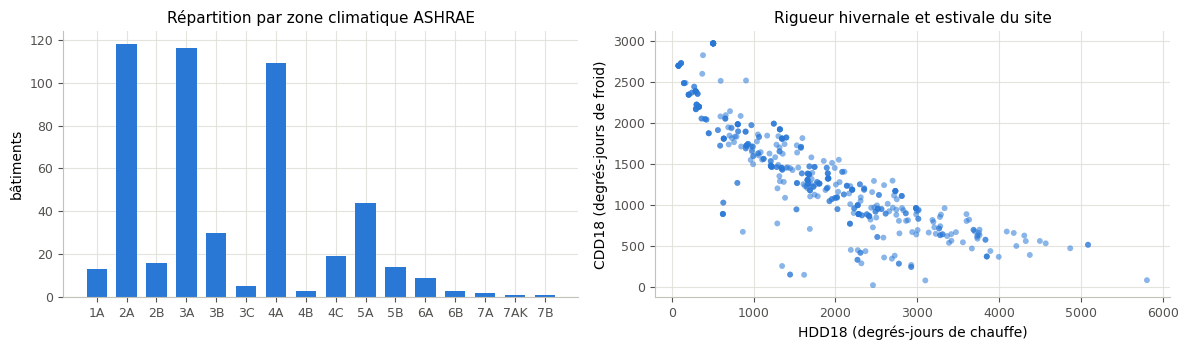

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

z = parc['in.ashrae_iecc_climate_zone_2004'].value_counts().sort_index()
axes[0].bar(z.index, z.values, color=COUL['total'], width=0.68)
deco(axes[0], 'Répartition par zone climatique ASHRAE', y='bâtiments')

# HDD vs CDD : chaque point est un bâtiment, la couleur n'encode rien -> une seule teinte
axes[1].scatter(parc['HDD18'], parc['CDD18'], s=18, alpha=0.55,
                color=COUL['total'], edgecolors='none')
deco(axes[1], 'Rigueur hivernale et estivale du site',
     'HDD18 (degrés-jours de chauffe)', 'CDD18 (degrés-jours de froid)')

plt.tight_layout(); plt.show()

### 1.3 Millésime et taille

Réparti sur toutes les décennies, avec un pic 1970-1980 (35 % du parc). Aucune classe ne domine :
le millésime est une vraie variable explicative et non une constante déguisée.

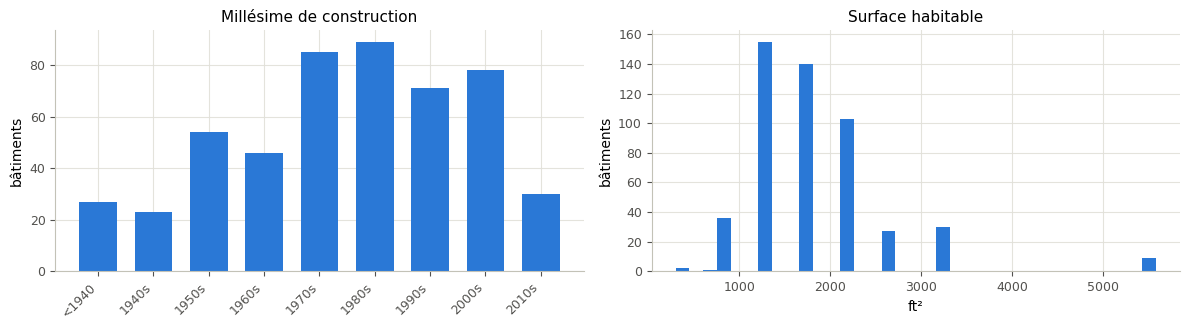

surface : médiane 1698 ft² | p10 1228 | p90 2678


In [5]:
ordre = ['<1940', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']
v = parc['in.vintage'].value_counts().reindex(ordre)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].bar(range(len(v)), v.values, color=COUL['total'], width=0.68)
axes[0].set_xticks(range(len(v))); axes[0].set_xticklabels(ordre, rotation=45, ha='right')
deco(axes[0], 'Millésime de construction', y='bâtiments')

axes[1].hist(parc['in.sqft..ft2'], bins=35, color=COUL['total'])
deco(axes[1], 'Surface habitable', 'ft²', 'bâtiments')
plt.tight_layout(); plt.show()

print(f"surface : médiane {parc['in.sqft..ft2'].median():.0f} ft² "
      f"| p10 {parc['in.sqft..ft2'].quantile(.1):.0f} "
      f"| p90 {parc['in.sqft..ft2'].quantile(.9):.0f}")

### 1.4 Équipements — ce qui décide quelles cibles existent

Le chauffage est électrique partout (c'est le filtre), mais **la clim et l'eau chaude ne le sont
pas** : 26 bâtiments n'ont aucune climatisation et 81 ont un chauffe-eau non électrique. Pour ces
bâtiments la cible correspondante est *strictement nulle toute l'année* — ce n'est pas une valeur
faible à prédire, c'est un zéro structurel. C'est exactement ce que le masque `GATE` de
`timeseries_net` impose au réseau plutôt que de le lui faire apprendre.

La coupure la plus lourde de conséquences est ailleurs : **48 % du parc est en pompe à chaleur**.

In [6]:
for c in ['in.hvac_cooling_type', 'in.water_heater_fuel', 'in.hvac_heating_type']:
    print(f'--- {c} ---')
    print(parc[c].value_counts().to_string(), '\n')

pac = parc['in.hvac_heating_type'].str.contains('Heat Pump')
print(f'pompe à chaleur : {pac.sum()}/{len(parc)} ({100*pac.mean():.0f} %)')
print(f"sans climatisation           : {(parc['in.hvac_cooling_type'] == 'None').sum()}")
print(f"chauffe-eau non électrique   : {(parc['in.water_heater_fuel'] != 'Electricity').sum()}")

--- in.hvac_cooling_type ---
in.hvac_cooling_type
Ducted Heat Pump        225
Central AC              188
Room AC                  47
None                     26
Non-Ducted Heat Pump     17 

--- in.water_heater_fuel ---
in.water_heater_fuel
Electricity      422
Natural Gas       57
Propane           19
Other Fuel         2
Solar Thermal      2
Fuel Oil           1 

--- in.hvac_heating_type ---
in.hvac_heating_type
Ducted Heat Pump        225
Ducted Heating          173
Non-Ducted Heating       88
Non-Ducted Heat Pump     17 

pompe à chaleur : 242/503 (48 %)
sans climatisation           : 26
chauffe-eau non électrique   : 81


### 1.5 Enveloppe physique

Les six agrégats construits dans `lgbm_electricity_5features`, plus la constante de temps
`tau = C / (UA + H_ve)` qui résume l'inertie thermique du bâtiment.

`tau` médian **15,8 h**, 80 % du parc entre 8 et 31 h. C'est le chiffre à retenir pour la suite
flexibilité : un bâtiment dont la constante de temps est de 16 h tolère une coupure de chauffage
de quelques heures sans dérive de température notable. L'étalement d'un facteur ~8 entre les
extrêmes dit aussi que le gisement d'effacement sera très inégal.

                  min       p10       méd       p90       max
UA              112.3     219.7     360.5     586.4    1499.0
H_ve             17.6      52.2     119.7     224.5     513.9
C              3045.3   12548.9   28153.3   59566.6  134948.4
A_solaire         1.0       2.4       4.7       8.1      21.5
compacite         0.8       1.0       1.2       1.3       1.8
DSE               0.6       0.7       0.9       1.0       1.0
tau               4.3       8.0      15.8      31.3      65.4


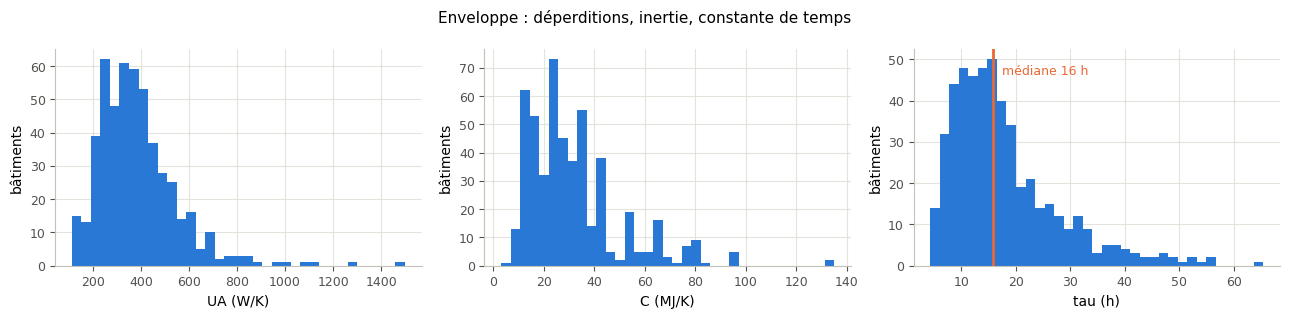

In [7]:
feat = pd.read_parquet(DATA / 'X_47features.parquet')
feat = feat.assign(tau=feat['C'] / (feat['UA'] + feat['H_ve']) / 3.6)
env = feat.loc[ids, ['UA', 'H_ve', 'C', 'A_solaire', 'compacite', 'DSE', 'tau']]

print(f"{'':11}{'min':>10}{'p10':>10}{'méd':>10}{'p90':>10}{'max':>10}")
for c in env.columns:
    s = env[c]
    print(f'{c:11}{s.min():10.1f}{s.quantile(.1):10.1f}{s.median():10.1f}'
          f'{s.quantile(.9):10.1f}{s.max():10.1f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (serie, lab) in zip(axes, [(env['UA'], 'UA (W/K)'),
                                   (env['C'] / 1000, 'C (MJ/K)'),
                                   (env['tau'], 'tau (h)')]):
    ax.hist(serie, bins=35, color=COUL['total'])
    deco(ax, '', lab, 'bâtiments')

# repère de la médiane : étiquette en haut de l'axe, hors des barres
med = env['tau'].median()
axes[2].axvline(med, color=COUL['chauffage'], lw=2)
axes[2].annotate(f'médiane {med:.0f} h', xy=(med, 1), xycoords=('data', 'axes fraction'),
                 xytext=(7, -11), textcoords='offset points',
                 color=COUL['chauffage'], fontsize=9, va='top')
plt.suptitle('Enveloppe : déperditions, inertie, constante de temps', fontsize=11)
plt.tight_layout(); plt.show()

## 2. Consommation annuelle

### 2.1 Niveaux et parts par usage

Les trois usages thermiques pèsent **61 % du total**. C'est la part pilotable — celle qui
intéresse l'étude de flexibilité — et c'est aussi ce qui rend la prédiction du `total` largement
tributaire de la qualité sur `chauffage` et `clim`.

In [8]:
ann = parc[TGT].copy()
ann.columns = USAGES

print(f"{'usage':12}{'moy':>9}{'méd':>9}{'p10':>9}{'p90':>9}{'max':>9}{'part':>8}")
tot = ann['total'].sum()
for u in USAGES:
    s = ann[u]
    part = f'{100*s.sum()/tot:6.1f} %' if u != 'total' else '      —'
    print(f'{u:12}{s.mean():9.0f}{s.median():9.0f}{s.quantile(.1):9.0f}'
          f'{s.quantile(.9):9.0f}{s.max():9.0f}{part:>8}')

print(f"\nusages thermiques = {100*ann[USAGES[1:]].sum().sum()/tot:.0f} % du total")
print('\n--- cibles structurellement nulles ---')
for u in USAGES[1:]:
    print(f'  {u:12} = 0 sur l\'année : {(ann[u] < 1).sum():3d} bâtiments '
          f'| < 100 kWh/an : {(ann[u] < 100).sum():3d}')

usage             moy      méd      p10      p90      max    part
total           21594    20168    11961    32558    68201       —
chauffage        6579     3925      346    16427    54564  30.5 %
clim             4690     4126      989     8761    28458  21.7 %
eau_chaude       1980     1896        0     3724     7461   9.2 %

usages thermiques = 61 % du total

--- cibles structurellement nulles ---
  chauffage    = 0 sur l'année :   2 bâtiments | < 100 kWh/an :  19
  clim         = 0 sur l'année :  26 bâtiments | < 100 kWh/an :  28
  eau_chaude   = 0 sur l'année :  79 bâtiments | < 100 kWh/an :  79


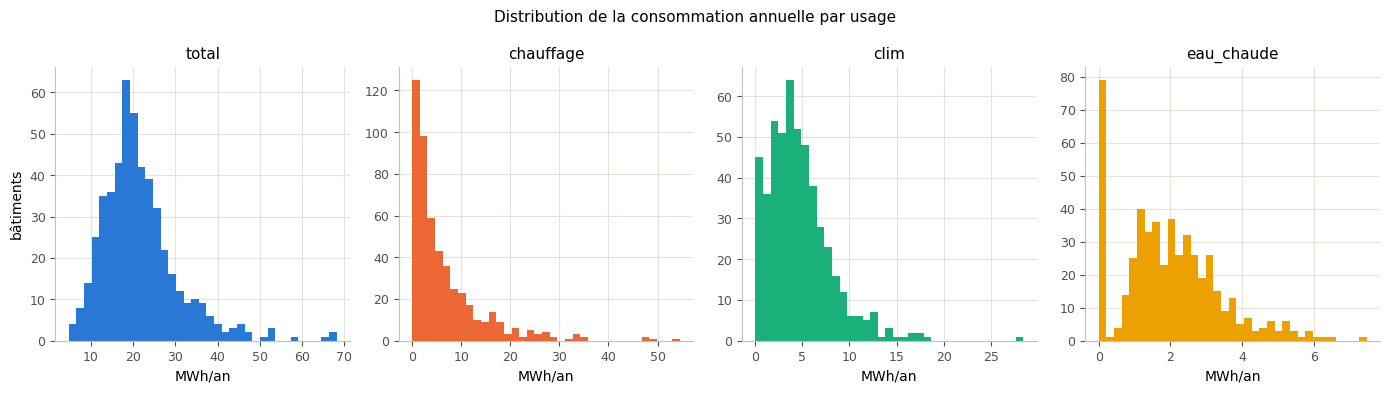

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.964))
for ax, u in zip(axes, USAGES):
    ax.hist(ann[u] / 1000, bins=35, color=COUL[u])
    deco(ax, u, 'MWh/an', 'bâtiments' if u == 'total' else '')
plt.suptitle('Distribution de la consommation annuelle par usage', fontsize=11)
plt.tight_layout(); plt.show()

### 2.2 Variabilité entre bâtiments — pourquoi le chauffage est la cible difficile

Le tableau ci-dessous est le plus important de la section. Le **chauffage varie d'un facteur 47
entre le décile bas et le décile haut** du parc (CV = 1,19), contre 2,7 pour le total. Deux
maisons du même parc peuvent consommer 346 et 16 400 kWh de chauffage par an.

Conséquences directes pour le modèle : c'est la cible où le vecteur statique `s` doit faire le
plus de travail (identifier *quel* bâtiment il simule), c'est celle qui se dégrade en premier
quand le parc rétrécit, et c'est celle dont le R² est le plus sensible au tirage de validation.

In [10]:
print(f"{'usage':12}{'CV':>7}{'p10':>9}{'p90':>9}{'p90/p10':>10}")
for u in USAGES:
    s = ann[u]
    p10, p90 = s.quantile(.1), s.quantile(.9)
    r = f'{p90/p10:.1f}' if p10 > 0 else 'infini'
    print(f'{u:12}{s.std()/s.mean():7.2f}{p10:9.0f}{p90:9.0f}{r:>10}')

usage            CV      p10      p90   p90/p10
total          0.42    11961    32558       2.7
chauffage      1.19      346    16427      47.5
clim           0.73      989     8761       8.9
eau_chaude     0.71        0     3724    infini


## 3. Formes de charge

Jusqu'ici, des totaux annuels. Mais le modèle prédit une courbe **horaire** : c'est la forme qui
compte. On agrège les 503 séries temporelles (6 s environ).

In [11]:
LOAD = np.zeros((len(ids), 8760, 4), dtype='float32')   # kWh horaires
TEMP = np.zeros((len(ids), 8760), dtype='float32')       # température extérieure
idx = None

for k, bid in enumerate(ids):
    ts = pd.read_parquet(DATA / f'{bid}-0.parquet', columns=['timestamp'] + TGT + [TEXT])
    ts['timestamp'] = pd.to_datetime(ts['timestamp'])
    ts = ts.set_index('timestamp')
    # kWh -> somme ; température -> moyenne (cf. load_building dans timeseries_net)
    y = ts[TGT].resample('1h').sum().iloc[:8760]
    LOAD[k] = y.values.astype('float32')
    TEMP[k] = ts[[TEXT]].resample('1h').mean().iloc[:8760].values.ravel().astype('float32')
    if idx is None:
        idx = y.index

heure, mois = idx.hour.values, idx.month.values
hiver, ete  = np.isin(mois, [12, 1, 2]), np.isin(mois, [6, 7, 8])
courbe = LOAD.sum(0)                    # (8760, 4) : le parc entier

# contrôle de cohérence avec les annuels de metadata_clean
ecart = 100 * abs(LOAD.sum(1)[:, 0].mean() - ann['total'].mean()) / ann['total'].mean()
print(f'annuel reconstitué {LOAD.sum(1)[:, 0].mean():.0f} kWh '
      f'vs metadata {ann["total"].mean():.0f} kWh  (écart {ecart:.2f} %)')

annuel reconstitué 21593 kWh vs metadata 21594 kWh  (écart 0.00 %)


### 3.1 La pointe du parc est une pointe matinale d'hiver

Le résultat le plus structurant de l'étude. La pointe de puissance appelée par les 503 bâtiments
tombe **en janvier, à 7 h du matin**, et non un après-midi d'août. Un parc tout-électrique se
comporte en parc thermosensible au chauffage : c'est la signature d'un réseau hivernal, comme en
France, et non celle du réseau américain moyen dominé par la clim.

Le **facteur de charge de 0,27** (moyenne / pointe) dit que le parc appelle presque quatre fois sa
puissance moyenne au moment le plus tendu. C'est précisément là que la flexibilité a de la valeur.

In [12]:
i_max = courbe[:, 0].argmax()
print(f'pointe du parc      {courbe[:, 0].max():8.0f} kWh/h  '
      f'-> {idx[i_max]:%d %B, %Hh}')
print(f'moyenne             {courbe[:, 0].mean():8.0f} kWh/h')
print(f'facteur de charge   {courbe[:, 0].mean()/courbe[:, 0].max():8.3f}')
print(f'\ncomposition à la pointe :')
for i, u in enumerate(USAGES[1:], start=1):
    print(f'  {u:12}{courbe[i_max, i]:8.0f} kWh/h '
          f'({100*courbe[i_max, i]/courbe[i_max, 0]:4.0f} % du total)')

# foisonnement : la pointe du parc est bien inférieure à la somme des pointes individuelles
pointes = LOAD[:, :, 0].max(1)
print(f'\nsomme des pointes individuelles {pointes.sum():.0f} kWh/h')
print(f'facteur de foisonnement         {courbe[:, 0].max()/pointes.sum():.3f}')

pointe du parc          4594 kWh/h  -> 02 January, 07h
moyenne                 1240 kWh/h
facteur de charge      0.270

composition à la pointe :
  chauffage       2797 kWh/h (  61 % du total)
  clim               9 kWh/h (   0 % du total)
  eau_chaude       233 kWh/h (   5 % du total)

somme des pointes individuelles 8071 kWh/h
facteur de foisonnement         0.569


### 3.2 Profil journalier : hiver et été s'opposent

Deux régimes distincts, et c'est la difficulté que le GRU doit absorber :

- **Hiver** : maximum le matin (8 h), le chauffage fait alors 62 % de l'appel.
- **Été** : maximum en fin d'après-midi (18 h), la clim suit l'ensoleillement avec quelques heures
  de retard sur le midi solaire.

Le creux de nuit hivernal reste haut (le chauffage ne s'arrête pas), alors que le creux de nuit
estival est profond. Un modèle qui n'aurait vu que la Floride — le cas `[:30]` — n'apprendrait
que la courbe de droite.

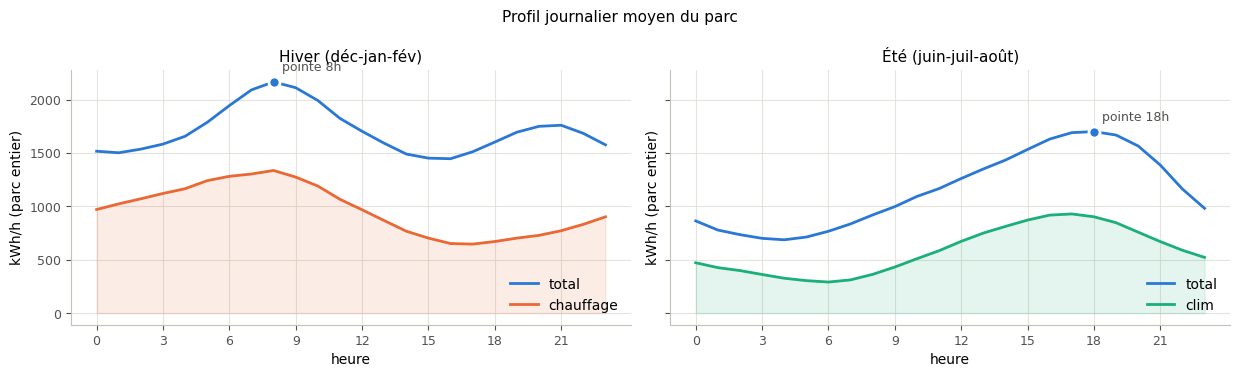

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)

for ax, (sel, titre, seco) in zip(axes, [(hiver, 'Hiver (déc-jan-fév)', 'chauffage'),
                                          (ete,   'Été (juin-juil-août)', 'clim')]):
    prof_tot = [courbe[(heure == h) & sel, 0].mean() for h in range(24)]
    prof_sec = [courbe[(heure == h) & sel, USAGES.index(seco)].mean() for h in range(24)]
    ax.plot(range(24), prof_tot, lw=2, color=COUL['total'], label='total')
    ax.plot(range(24), prof_sec, lw=2, color=COUL[seco], label=seco)
    ax.fill_between(range(24), prof_sec, color=COUL[seco], alpha=0.12)
    h_max = int(np.argmax(prof_tot))
    ax.plot([h_max], [prof_tot[h_max]], 'o', ms=8, color=COUL['total'],
            mec='white', mew=2, zorder=5)
    ax.annotate(f'pointe {h_max}h', (h_max, prof_tot[h_max]), xytext=(6, 8),
                textcoords='offset points', fontsize=9, color=ENCRE)
    deco(ax, titre, 'heure', 'kWh/h (parc entier)')
    ax.set_xticks(range(0, 24, 3)); ax.legend(loc='lower right')

plt.suptitle('Profil journalier moyen du parc', fontsize=11)
plt.tight_layout(); plt.show()

### 3.3 Saisonnalité

Le mois le plus chargé (janvier, 2 123 kWh/h) appelle **2,3 fois** le mois le plus creux (mai,
929 kWh/h). Chauffage et clim se relaient sans se recouvrir : en mai le chauffage est déjà à
22 kWh/h et la clim monte à 354 — les intersaisons sont les seules périodes où les deux sont
faibles simultanément.

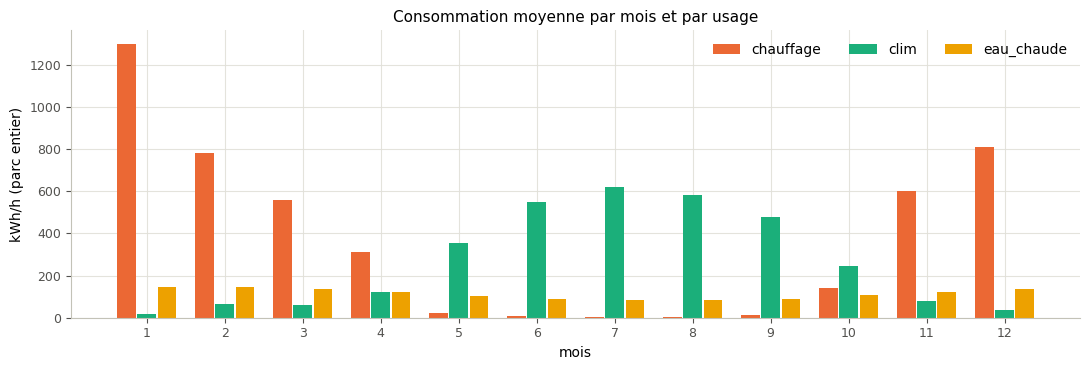

 mois    total  chauffage    clim  eau_chaude   T_ext
    1     2123       1299      19         146     5.6
    2     1510        783      63         144    10.9
    3     1199        560      62         136    11.6
    4      980        310     124         122    15.1
    5      929         22     354         105    22.7
    6     1119          7     550          91    25.4
    7     1189          4     621          83    26.5
    8     1146          4     583          83    25.9
    9     1047         12     478          91    24.0
   10      925        142     247         106    18.0
   11     1249        603      77         123    10.6
   12     1471        809      38         137     8.7


In [14]:
fig, ax = plt.subplots(figsize=(11, 3.8))
larg, x = 0.26, np.arange(1, 13)
for k, u in enumerate(USAGES[1:]):
    m = [courbe[mois == mo, USAGES.index(u)].mean() for mo in range(1, 13)]
    # 2px d'écart entre barres voisines -> largeur légèrement réduite
    ax.bar(x + (k - 1) * larg, m, width=larg * 0.92, color=COUL[u], label=u)
deco(ax, 'Consommation moyenne par mois et par usage', 'mois', 'kWh/h (parc entier)')
ax.set_xticks(x); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

print(f"{'mois':>5}{'total':>9}{'chauffage':>11}{'clim':>8}{'eau_chaude':>12}{'T_ext':>8}")
for mo in range(1, 13):
    s = mois == mo
    print(f'{mo:5d}' + ''.join(f'{courbe[s, i].mean():9.0f}' if i == 0 else
          (f'{courbe[s, i].mean():11.0f}' if i == 1 else
           (f'{courbe[s, i].mean():8.0f}' if i == 2 else f'{courbe[s, i].mean():12.0f}'))
          for i in range(4)) + f'{TEMP[:, s].mean():8.1f}')

### 3.4 Thermosensibilité

La courbe en U : le parc consomme le moins entre 20 et 25 °C et remonte des deux côtés. La branche
froide est **beaucoup plus raide** que la branche chaude — en dessous de 0 °C le parc appelle
3 349 kWh/h contre 1 385 au-dessus de 25 °C, soit 2,4 fois plus.

Deux axes, deux échelles : on porte la température en abscisse plutôt que de superposer deux
séries temporelles sur des ordonnées différentes.

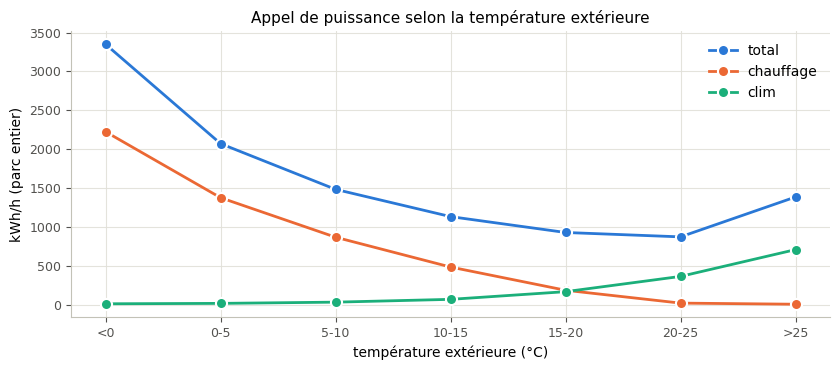

   T_ext  heures    total  chauffage    clim
      <0     155     3349       2224      11
     0-5     443     2071       1376      16
    5-10    1379     1483        867      32
   10-15    1855     1133        484      68
   15-20    1151      928        185     167
   20-25    1991      872         20     363
     >25    1786     1385          5     708


In [15]:
t_parc = TEMP.mean(0)
bornes = [-100, 0, 5, 10, 15, 20, 25, 100]
etiq   = ['<0', '0-5', '5-10', '10-15', '15-20', '20-25', '>25']
cat    = np.digitize(t_parc, bornes[1:-1])

fig, ax = plt.subplots(figsize=(8.5, 3.8))
xs = np.arange(len(etiq))
for u in USAGES[:3]:
    i = USAGES.index(u)
    ax.plot(xs, [courbe[cat == k, i].mean() for k in range(len(etiq))],
            lw=2, marker='o', ms=8, mec='white', mew=1.5, color=COUL[u], label=u)
ax.set_xticks(xs); ax.set_xticklabels(etiq)
deco(ax, 'Appel de puissance selon la température extérieure',
     'température extérieure (°C)', 'kWh/h (parc entier)')
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'T_ext':>8}{'heures':>8}{'total':>9}{'chauffage':>11}{'clim':>8}")
for k, e in enumerate(etiq):
    s = cat == k
    print(f'{e:>8}{s.sum():8d}{courbe[s,0].mean():9.0f}'
          f'{courbe[s,1].mean():11.0f}{courbe[s,2].mean():8.0f}')

### 3.5 Pompe à chaleur ou effet Joule : deux populations dans une seule cible

À climat identique (HDD18 médian 1 659 contre 1 660 — les deux groupes sont climatiquement
superposables), les bâtiments en PAC consomment **3 205 kWh/an** de chauffage contre **9 695** pour
les autres. Normalisé par les degrés-jours et la surface, le rapport est de **2,7**.

C'est la principale source de la dispersion vue en 2.2, et c'est une information que le réseau ne
peut pas deviner de la météo : elle doit venir du vecteur statique. `in.hvac_heating_type` mérite
d'être vérifié dans les 48 features — s'il n'y figure pas, c'est un ajout à tester en priorité.

In [16]:
annuel = LOAD.sum(1)
pac_v  = pac.values
hdd, sqft = parc['HDD18'].values, parc['in.sqft..ft2'].values
ok = ~np.isnan(hdd)

print(f"{'':18}{'n':>5}{'chauffage':>12}{'HDD18 méd':>11}{'kWh/(HDD·1000ft²)':>20}")
for nom, sel in [('PAC', pac_v & ok), ('résistance/autre', (~pac_v) & ok)]:
    inten = np.mean(annuel[sel, 1] / np.maximum(hdd[sel], 1) / (sqft[sel] / 1000))
    print(f'{nom:18}{sel.sum():5d}{annuel[sel,1].mean():12.0f}'
          f'{np.median(hdd[sel]):11.0f}{inten:20.2f}')

print('\nin.hvac_heating_type présent dans X_47features :',
      'in.hvac_heating_type' in feat.columns)

                      n   chauffage  HDD18 méd   kWh/(HDD·1000ft²)
PAC                 242        3205       1659                1.12
résistance/autre    260        9695       1660                3.04

in.hvac_heating_type présent dans X_47features : False


## 4. Aptitude à l'entraînement

### 4.1 Représentativité — le parc est un bon échantillon

On compare les 503 à la population ResStock qui satisfait *exactement les mêmes filtres*
(maison individuelle, chauffage électrique, occupée) : **96 316 bâtiments**. Les 503 en
représentent 0,52 %.

Le résultat est net : l'écart maximal sur les zones climatiques est de **1,8 point**, la surface
médiane est identique au pied près (1 698 ft²), et les millésimes se superposent. Le parc consomme
5 à 10 % de moins que la population — léger biais vers des bâtiments plus sobres, à mentionner
mais sans gravité.

**Le tirage des 503 n'est donc pas en cause dans la régression du 03/08.** Le parc est sain ; seule
la tranche `[:30]` l'était pas.

In [17]:
pop = meta[(meta['upgrade'] == 0)
           & (meta['in.geometry_building_type_recs'] == 'Single-Family Detached')
           & (meta['in.heating_fuel'] == 'Electricity')
           & (meta['in.vacancy_status'] == 'Occupied')]
print(f'population éligible : {len(pop)} bâtiments | les 503 = {100*len(ids)/len(pop):.2f} %\n')

a = parc['in.ashrae_iecc_climate_zone_2004'].value_counts(normalize=True).mul(100)
b = pop['in.ashrae_iecc_climate_zone_2004'].value_counts(normalize=True).mul(100)
cmp = pd.DataFrame({'parc_503': a, 'ResStock': b}).fillna(0)
cmp['écart'] = cmp['parc_503'] - cmp['ResStock']
print(cmp.sort_values('ResStock', ascending=False).head(8).round(1).to_string())
print(f"\nécart absolu maximal : {cmp['écart'].abs().max():.1f} point\n")

print(f"{'usage':12}{'parc 503':>11}{'ResStock':>11}{'écart':>9}")
for u, t in zip(USAGES, TGT):
    x, y = parc[t].mean(), pop[t].mean()
    print(f'{u:12}{x:11.0f}{y:11.0f}{100*(x-y)/y:8.1f} %')
print(f"\nsurface médiane : parc {parc['in.sqft..ft2'].median():.0f} ft² "
      f"| population {pop['in.sqft..ft2'].median():.0f} ft²")

population éligible : 96316 bâtiments | les 503 = 0.52 %

                                  parc_503  ResStock  écart
in.ashrae_iecc_climate_zone_2004                           
2A                                    23.5      25.2   -1.8
3A                                    23.1      21.7    1.4
4A                                    21.7      20.9    0.8
5A                                     8.7       8.6    0.2
3B                                     6.0       6.2   -0.3
2B                                     3.2       3.9   -0.7
4C                                     3.8       3.5    0.2
1A                                     2.6       3.1   -0.5

écart absolu maximal : 1.8 point

usage          parc 503   ResStock    écart
total             21594      23441    -7.9 %
chauffage          6579       7290    -9.8 %
clim               4690       4931    -4.9 %
eau_chaude         1980       1987    -0.3 %

surface médiane : parc 1698 ft² | population 1698 ft²


### 4.2 Audit du découpage train / validation

On rejoue exactement le découpage de `timeseries_net` (graine 42, 20 % des bâtiments) et on
vérifie que la validation ressemble à l'entraînement. Elle y ressemble : écart de 0,5 % sur le
total, 4,4 % sur le chauffage, HDD18 quasi identiques.

Le seul écart notable est l'**eau chaude, à −13 %**, parce que le tirage a mis 19 bâtiments sans
ECS électrique en validation (18,8 %) contre 16 % dans le parc. Le R² « eau_chaude » est donc
mesuré sur une validation un peu plus pauvre que la moyenne — à garder en tête avant de conclure
quoi que ce soit sur cet usage.

In [18]:
SEQ_LEN = 168
bids = np.repeat(ids, 8760 // SEQ_LEN)
rng  = np.random.default_rng(42)
uniq = np.unique(bids)
val_b = set(rng.choice(uniq, size=max(1, round(0.2 * len(uniq))), replace=False))
val = np.array([b in val_b for b in bids]); tr = ~val
print(f'{len(val_b)} bâtiments en validation / {len(uniq)-len(val_b)} en entraînement '
      f'| {val.sum()} fenêtres / {tr.sum()}\n')

pos = {b: k for k, b in enumerate(ids)}
iv = np.array([pos[b] for b in sorted(val_b)])
it = np.array([pos[b] for b in ids if b not in val_b])

print(f"{'usage':12}{'train':>10}{'val':>10}{'écart':>9}")
for i, u in enumerate(USAGES):
    x, y = annuel[it, i].mean(), annuel[iv, i].mean()
    print(f'{u:12}{x:10.0f}{y:10.0f}{100*(y-x)/x:8.1f} %')
print(f'\nHDD18 moyen : train {np.nanmean(hdd[it]):.0f} | val {np.nanmean(hdd[iv]):.0f}')
print(f'validation sans ECS électrique : {(annuel[iv,3] < 1).sum()}/{len(iv)} '
      f'({100*(annuel[iv,3] < 1).mean():.1f} %) contre {100*(annuel[:,3] < 1).mean():.1f} % dans le parc')

101 bâtiments en validation / 402 en entraînement | 5252 fenêtres / 20904

usage            train       val    écart
total            21613     21515    -0.5 %
chauffage         6521      6808     4.4 %
clim              4642      4878     5.1 %
eau_chaude        2034      1768   -13.0 %

HDD18 moyen : train 1733 | val 1697
validation sans ECS électrique : 19/101 (18.8 %) contre 15.7 % dans le parc


### 4.3 Le R² dépend du tirage — de combien ?

Question de méthode : quand on compare deux variantes du modèle à 0,01 de R² près, mesure-t-on
l'effet de la variante ou celui du tirage ? On fait varier la graine.

Le chauffage annuel moyen du lot de validation oscille entre 5 701 et 6 956 kWh/an selon la
graine, soit **±10 % autour de la moyenne du parc**. Deux conclusions pratiques : garder la graine
42 fixe pour toute comparaison A/B (ce que fait déjà `timeseries_net`), et **ne pas interpréter un
écart de R² inférieur à ~0,02** comme un effet réel sans le rejouer sur plusieurs graines.

In [19]:
print(f"{'graine':>8}{'chauffage val':>15}{'part du parc':>14}{'n < 100 kWh':>13}")
for g in [0, 1, 7, 42, 99, 123, 2024]:
    r  = np.random.default_rng(g)
    vb = set(r.choice(uniq, size=round(0.2 * len(uniq)), replace=False))
    k  = np.array([pos[b] for b in sorted(vb)])
    marque = '  <- utilisée' if g == 42 else ''
    print(f'{g:8d}{annuel[k,1].mean():15.0f}'
          f'{100*annuel[k,1].sum()/annuel[:,1].sum():13.1f} %{(annuel[k,1] < 100).sum():13d}{marque}')

  graine  chauffage val  part du parc  n < 100 kWh
       0           6010         18.3 %            5
       1           6491         19.8 %            4
       7           6956         21.2 %            5
      42           6808         20.8 %            6  <- utilisée
      99           5701         17.4 %            3
     123           6791         20.7 %            5
    2024           6814         20.8 %            5


### 4.4 Taille du parc contre dimension du vecteur statique

Le vecteur `s` fait 54 colonnes. Le réseau doit apprendre à identifier un bâtiment à partir de ces
54 nombres, en ne voyant que les bâtiments d'entraînement. Le rapport
*bâtiments d'entraînement / colonnes de `s`* mesure la marge avant mémorisation, et il explique
l'historique noté dans `timeseries_net` :

| parc | entraînement | `s` | ratio | effet des 48 features |
|---|---|---|---|---|
| 153 (29/07) | 122 | 52 | **2,3** | dégradait — le réseau mémorisait |
| 503 (31/07) | 402 | 52 | **7,7** | améliorait : total +0.031, chauffage +0.044 |
| 30 (03/08) | 24 | 54 | **0,4** | moins de bâtiments que de colonnes |

À 30 bâtiments le rapport passe **sous 1** : il y a strictement moins d'exemples que de dimensions
à démêler. La régression observée n'a rien d'un mystère.

In [20]:
for n_bat, n_s, quand in [(153, 52, '29/07'), (503, 52, '31/07'), (30, 54, '03/08'), (len(ids), 54, 'actuel')]:
    n_tr = n_bat - round(0.2 * n_bat)
    print(f'{quand:8} {n_bat:4d} bâtiments -> {n_tr:4d} en entraînement '
          f'| s = {n_s} colonnes | ratio {n_tr/n_s:5.1f}')

29/07     153 bâtiments ->  122 en entraînement | s = 52 colonnes | ratio   2.3
31/07     503 bâtiments ->  402 en entraînement | s = 52 colonnes | ratio   7.7
03/08      30 bâtiments ->   24 en entraînement | s = 54 colonnes | ratio   0.4
actuel    503 bâtiments ->  402 en entraînement | s = 54 colonnes | ratio   7.4


### 4.5 Ce que les consignes apportent vraiment

Les consignes de thermostat ont été reconstruites et injectées le 03/08 (commit
« reconstruction et injection des consignes »), portant `f(t)` de 27 à 31 entrées. Elles sont
saines — aucune valeur manquante, plage 18-24 °C plausible — mais **environ la moitié des
bâtiments ont une consigne strictement constante sur l'année**, et l'écart-type intra-annuel
médian est nul.

Autrement dit, les 2 colonnes de consigne dans `f(t)` sont de l'information *statique* recopiée sur
8 760 pas de temps. Leur variabilité utile est **entre** bâtiments (écart-type 2,1 °C en chauffage,
2,3 °C en clim), pas dans le temps. Ce qui apporte réellement du signal temporel, ce sont les deux
colonnes d'**écart à la consigne**, qui varient parce que la température extérieure varie.

À tester : déplacer les 2 consignes de `f(t)` vers le vecteur statique `s` et ne garder que les
écarts dans la partie temporelle. Le GRU traiterait 29 entrées au lieu de 31, sans perte
d'information.

In [21]:
ech = ids[:150]        # échantillon : la lecture complète n'apporterait rien de plus
const_h = const_c = 0
for bid in ech:
    ts = pd.read_parquet(DATA / f'{bid}-0.parquet', columns=['timestamp'] + SETP)
    ts['timestamp'] = pd.to_datetime(ts['timestamp'])
    h = ts.set_index('timestamp')[SETP].resample('1h').mean().iloc[:8760]
    const_h += h[SETP[0]].nunique() == 1
    const_c += h[SETP[1]].nunique() == 1

print(f'sur {len(ech)} bâtiments :')
print(f'  consigne de chauffage strictement constante : {const_h} ({100*const_h/len(ech):.0f} %)')
print(f'  consigne de clim strictement constante      : {const_c} ({100*const_c/len(ech):.0f} %)')
print(f"\nvariabilité INTER-bâtiments (écart-type) : "
      f"chauffage {feat.loc[ids,'in.heating_setpoint'].std():.1f} °C | "
      f"clim {feat.loc[ids,'in.cooling_setpoint'].std():.1f} °C")

sur 150 bâtiments :
  consigne de chauffage strictement constante : 77 (51 %)
  consigne de clim strictement constante      : 79 (53 %)

variabilité INTER-bâtiments (écart-type) : chauffage 2.1 °C | clim 2.3 °C


## 5. Synthèse

**Le parc est sain et l'échantillonnage est bon.** 503 bâtiments tirés de 96 316 éligibles, avec
un écart maximal de 1,8 point sur les zones climatiques et une surface médiane identique. Le
découpage train/validation à la graine 42 est équilibré. Rien à corriger de ce côté.

**Ce qu'il faut savoir en s'en servant :**

1. **Domaine de validité borné.** 100 % maisons individuelles occupées à chauffage électrique. Le
   simulateur ne dit rien du collectif, du chauffage gaz ni du tertiaire — à préciser dans toute
   restitution.
2. **Le chauffage est la cible difficile**, avec un rapport de 47 entre déciles. Sa dispersion
   vient largement de la coupure PAC / effet Joule (rapport 2,7 à climat égal) : une information
   purement statique, que le réseau ne peut pas déduire de la météo.
3. **Ne jamais sous-échantillonner par tranche.** `nn_buildings.csv` est groupé par état ; un
   `head(n)` change le climat en même temps que la taille. Utiliser `sample()`.
4. **Un écart de R² sous ~0,02 n'est pas un résultat** : c'est l'ordre de grandeur du bruit de
   tirage mesuré en 4.3.

**Pistes ouvertes, par ordre d'intérêt :**

- Ajouter `in.hvac_heating_type` (ou le COP) au vecteur statique s'il n'y figure pas — c'est la
  variable qui sépare le mieux les deux populations de chauffage (§ 3.5).
- Déplacer les 2 consignes de `f(t)` vers `s`, ne garder que les écarts dans la partie temporelle
  (§ 4.5).
- Pour la flexibilité (`07_flexibilite`) : la pointe du parc est **matinale et hivernale**
  (janvier, 7 h), le facteur de charge vaut 0,27 et `tau` médian 15,8 h. Le gisement est sur le
  chauffage au petit matin d'hiver, pas sur la clim d'été.